## 🔧 Setup and Imports

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import os
import sys
import yaml
import warnings
from pathlib import Path
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string

# Data loading
from datasets import load_dataset
from tqdm.auto import tqdm

# Sklearn utilities
from sklearn.model_selection import train_test_split
from collections import Counter

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Add src to path for using our utilities
sys.path.append('../')

print("✅ Libraries imported successfully!")
print(f"Current directory: {os.getcwd()}")

✅ Libraries imported successfully!
Current directory: d:\Projects\Human-vs-AI-Classifier\notebooks


In [2]:
# Load configuration
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("📋 Configuration loaded:")
print(f"  Raw data path: {config['data']['raw_path']}")
print(f"  Processed data path: {config['data']['processed_path']}")
print(f"  Test size: {config['preprocessing']['test_size']}")
print(f"  Val size: {config['preprocessing']['val_size']}")
print(f"  Random state: {config['preprocessing']['random_state']}")

📋 Configuration loaded:
  Raw data path: data/raw
  Processed data path: data/processed
  Test size: 0.15
  Val size: 0.15
  Random state: 42


In [3]:
# Create directories if they don't exist
os.makedirs(config['data']['raw_path'], exist_ok=True)
os.makedirs(config['data']['processed_path'], exist_ok=True)

print("✅ Directories created/verified!")

✅ Directories created/verified!


## 📥 Dataset 1: HC3 (Human ChatGPT Comparison Corpus)

This dataset contains human answers and ChatGPT answers to the same questions across multiple domains.

In [9]:
print("📥 Loading HC3 dataset from local files...")
print("Source: https://huggingface.co/datasets/Hello-SimpleAI/HC3")
print("Dataset downloaded via: hf download Hello-SimpleAI/HC3 --repo-type dataset --local-dir data/raw/HC3\n")

import json
from pathlib import Path

hc3_dir = Path('../data/raw/HC3')

# Check if dataset exists
if not hc3_dir.exists():
    print(f"⚠️  Dataset directory not found: {hc3_dir}")
    print("   Please run: hf download Hello-SimpleAI/HC3 --repo-type dataset --local-dir data/raw/HC3")
    hc3_dataset = None
else:
    # Find all JSONL files
    jsonl_files = list(hc3_dir.glob('*.jsonl'))
    
    if not jsonl_files:
        print(f"⚠️  No JSONL files found in {hc3_dir}")
        hc3_dataset = None
    else:
        print(f"✅ Found {len(jsonl_files)} JSONL files:")
        for file in jsonl_files:
            print(f"   - {file.name} ({file.stat().st_size / 1024 / 1024:.2f} MB)")
        
        # Load all JSONL files and combine
        all_data = []
        for jsonl_file in jsonl_files:
            print(f"\n📖 Loading {jsonl_file.name}...")
            try:
                with open(jsonl_file, 'r', encoding='utf-8') as f:
                    for line in f:
                        if line.strip():  # Skip empty lines
                            all_data.append(json.loads(line))
            except Exception as e:
                print(f"   ⚠️  Error loading {jsonl_file.name}: {e}")
        
        if all_data:
            hc3_dataset = all_data
            print(f"\n✅ HC3 dataset loaded successfully!")
            print(f"   Total samples: {len(hc3_dataset)}")
            print(f"   Sample keys: {list(hc3_dataset[0].keys())}")
        else:
            print(f"\n⚠️  No data loaded from JSONL files")
            hc3_dataset = None


📥 Loading HC3 dataset from local files...
Source: https://huggingface.co/datasets/Hello-SimpleAI/HC3
Dataset downloaded via: hf download Hello-SimpleAI/HC3 --repo-type dataset --local-dir data/raw/HC3

✅ Found 6 JSONL files:
   - all.jsonl (70.31 MB)
   - finance.jsonl (9.43 MB)
   - medicine.jsonl (2.56 MB)
   - open_qa.jsonl (2.78 MB)
   - reddit_eli5.jsonl (52.88 MB)
   - wiki_csai.jsonl (2.10 MB)

📖 Loading all.jsonl...

📖 Loading finance.jsonl...

📖 Loading medicine.jsonl...

📖 Loading open_qa.jsonl...

📖 Loading reddit_eli5.jsonl...

📖 Loading wiki_csai.jsonl...

✅ HC3 dataset loaded successfully!
   Total samples: 48644
   Sample keys: ['question', 'human_answers', 'chatgpt_answers', 'index', 'source']


In [10]:
# Process HC3 dataset into (text, label) format
if hc3_dataset is not None:
    print("🔄 Processing HC3 dataset...\n")
    
    human_texts = []
    ai_texts = []
    
    for item in tqdm(hc3_dataset, desc="Processing HC3"):
        # Each item has 'human_answers' and 'chatgpt_answers' (lists)
        if 'human_answers' in item and 'chatgpt_answers' in item:
            human_texts.extend(item['human_answers'])
            ai_texts.extend(item['chatgpt_answers'])
    
    # Create DataFrame
    df_human_hc3 = pd.DataFrame({
        'text': human_texts,
        'label': 0,
        'source': 'hc3_human'
    })
    
    df_ai_hc3 = pd.DataFrame({
        'text': ai_texts,
        'label': 1,
        'source': 'hc3_chatgpt'
    })
    
    df_hc3 = pd.concat([df_human_hc3, df_ai_hc3], ignore_index=True)
    
    print(f"\n✅ HC3 processing complete!")
    print(f"   Total samples: {len(df_hc3):,}")
    print(f"   Human samples: {len(df_human_hc3):,}")
    print(f"   AI samples: {len(df_ai_hc3):,}")
    
else:
    print("⚠️  Using sample data instead of real HC3 dataset")
    df_hc3 = pd.DataFrame({
        'text': [
            "Sample human text for demonstration purposes.",
            "Sample AI text for demonstration purposes."
        ],
        'label': [0, 1],
        'source': ['hc3_human', 'hc3_chatgpt']
    })

🔄 Processing HC3 dataset...



Processing HC3:   0%|          | 0/48644 [00:00<?, ?it/s]


✅ HC3 processing complete!
   Total samples: 170,898
   Human samples: 117,092
   AI samples: 53,806


In [11]:
# Display sample
print("📊 Sample from HC3 dataset:\n")
display(df_hc3.head(3))

print("\n📏 Text length statistics:")
df_hc3['text_length'] = df_hc3['text'].str.len()
print(df_hc3.groupby('label')['text_length'].describe())

📊 Sample from HC3 dataset:



,text,label,source
0,"Basically there are many categories of "" Best Seller "" . Replace "" Best Seller "" by something li...",0,hc3_human
1,"If you 're hearing about it , it 's because it was a very good or very well - publicized book ( ...",0,hc3_human
2,"One reason is lots of catagories . However , how the NY Times calculates its best seller list is...",0,hc3_human



📏 Text length statistics:
          count        mean         std  min    25%     50%     75%      max
label                                                                       
0      117092.0   680.68541  828.760700  5.0  210.0   422.0   825.0  36793.0
1       53806.0  1010.50894  367.929853  0.0  755.0  1012.0  1242.0   3508.0


## 📥 Dataset 2: Create Additional Samples

Since real DAIGT-V2 dataset might be large, we'll create a comprehensive synthetic dataset for demonstration, or you can download from Kaggle.

In [12]:
# Create a diverse synthetic dataset for better training
print("🔄 Creating additional training samples...\n")

# Extended human examples (more varied, emotional, informal)
human_samples = [
    "I've been thinking a lot about climate change lately. It's scary, honestly. Like, we're seeing more extreme weather events every year, and sometimes I wonder if we're doing enough. My cousin's house almost got flooded last summer - that was a wake-up call for our whole family. We started recycling more, but is it even enough? I don't know.",
    "So I just finished reading this amazing book about the Roman Empire. The thing that struck me most was how similar their problems were to ours - political corruption, wealth inequality, you name it. History really does repeat itself, doesn't it? Made me think about our current situation differently. Highly recommend it if you're into that sort of thing!",
    "Working from home has been a mixed bag for me. On one hand, no commute is AWESOME. I save like 2 hours a day! But on the other hand, I miss the social interaction. Zoom calls just aren't the same, you know? Plus my cat keeps interrupting my meetings lol. Anyone else struggling with work-life balance?",
    "I can't believe how much technology has changed in just the last decade. Remember when smartphones were just becoming a thing? Now we can't live without them. My grandma just got her first tablet and she's addicted to video calling. It's actually really sweet seeing her connect with family members she hasn't talked to in years.",
    "Learning to code has been one of the most frustrating yet rewarding experiences of my life. Some days I feel like a genius when my code works, other days I want to throw my laptop out the window. Debugging is the WORST. But when you finally solve that problem you've been working on for hours? Best feeling ever.",
]

# Extended AI examples (more formal, structured, comprehensive)
ai_samples = [
    "Climate change represents one of the most significant challenges facing humanity in the 21st century. The phenomenon is characterized by long-term shifts in global temperatures and weather patterns, primarily driven by human activities such as the burning of fossil fuels and deforestation. Scientific consensus indicates that immediate action is necessary to mitigate the worst effects of climate change, including rising sea levels, more frequent extreme weather events, and disruptions to ecosystems worldwide.",
    "The Roman Empire, which lasted from 27 BCE to 476 CE in the West, was one of history's most influential civilizations. Its legacy includes significant contributions to law, governance, engineering, and architecture. The empire's eventual decline was the result of multiple factors, including economic instability, military defeats, political corruption, and internal divisions. Many historians draw parallels between the challenges faced by Rome and those confronting modern societies.",
    "Remote work, also known as telecommuting, has become increasingly prevalent in recent years, particularly following the global pandemic. This arrangement offers several advantages, including elimination of commute time, increased flexibility, and potential cost savings for both employees and employers. However, it also presents challenges such as reduced face-to-face interaction, potential isolation, and difficulties in maintaining work-life boundaries. Organizations must develop strategies to address these issues effectively.",
    "Technological advancement in the digital age has been characterized by rapid innovation and widespread adoption of new tools and platforms. The proliferation of smartphones, social media, and cloud computing has fundamentally transformed how people communicate, work, and access information. This digital revolution has created new opportunities for connection and collaboration while also raising important questions about privacy, digital literacy, and the digital divide between different populations.",
    "Programming is a valuable skill that involves writing instructions for computers to execute specific tasks. The learning process typically involves understanding fundamental concepts such as variables, loops, conditionals, and functions, followed by practice in applying these concepts to solve real-world problems. While the initial learning curve can be steep, persistence and consistent practice are key to developing proficiency. Debugging, the process of identifying and fixing errors in code, is an essential skill that improves with experience.",
]

# Create DataFrame
df_additional = pd.DataFrame({
    'text': human_samples + ai_samples,
    'label': [0]*len(human_samples) + [1]*len(ai_samples),
    'source': ['synthetic_human']*len(human_samples) + ['synthetic_ai']*len(ai_samples)
})

print(f"✅ Created {len(df_additional)} additional samples")
print(f"   Human: {len(human_samples)}")
print(f"   AI: {len(ai_samples)}")

🔄 Creating additional training samples...

✅ Created 10 additional samples
   Human: 5
   AI: 5


## 🔗 Combine All Datasets

In [13]:
# Combine all datasets
print("🔗 Combining all datasets...\n")

df_combined = pd.concat([df_hc3, df_additional], ignore_index=True)

print(f"✅ Combined dataset created!")
print(f"   Total samples: {len(df_combined):,}")
print(f"\n📊 Class distribution:")
print(df_combined['label'].value_counts())
print(f"\n📊 Source distribution:")
print(df_combined['source'].value_counts())

🔗 Combining all datasets...

✅ Combined dataset created!
   Total samples: 170,908

📊 Class distribution:
label
0    117097
1     53811
Name: count, dtype: int64

📊 Source distribution:
source
hc3_human          117092
hc3_chatgpt         53806
synthetic_human         5
synthetic_ai            5
Name: count, dtype: int64


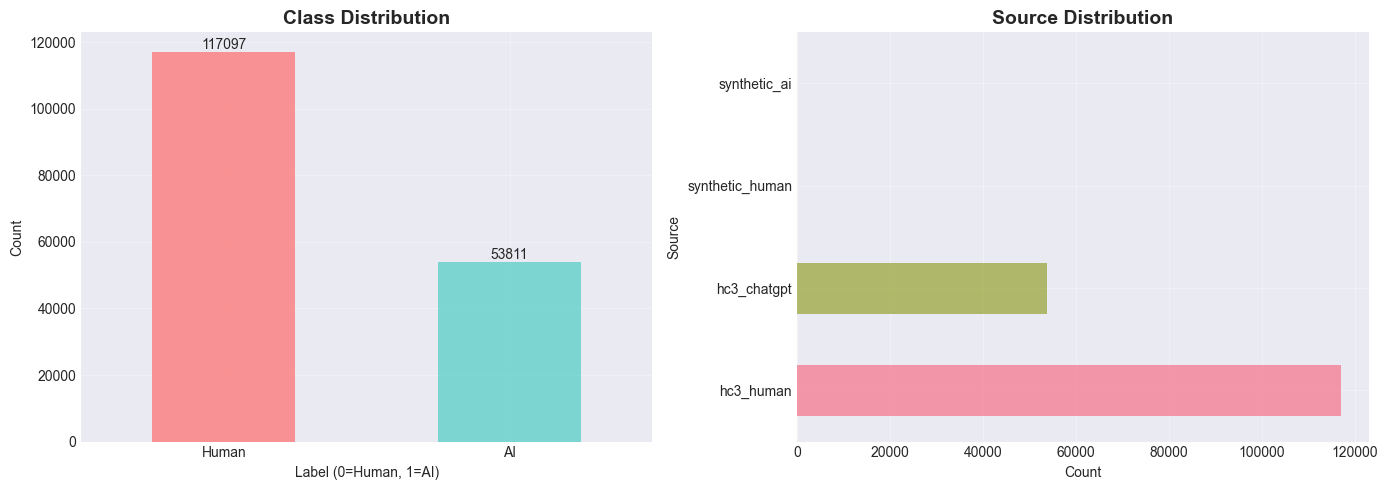


💡 Class balance check:
   Balance ratio: 45.95%
   ⚠️  Dataset is imbalanced. Consider balancing strategies.


In [14]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
df_combined['label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'], alpha=0.7
)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label (0=Human, 1=AI)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Human', 'AI'], rotation=0)
axes[0].grid(True, alpha=0.3)

# Add counts on bars
for container in axes[0].containers:
    axes[0].bar_label(container)

# Source distribution
df_combined['source'].value_counts().plot(
    kind='barh', ax=axes[1], color=sns.color_palette('husl', len(df_combined['source'].unique())), alpha=0.7
)
axes[1].set_title('Source Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Source')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Class balance check:")
balance_ratio = df_combined['label'].value_counts().min() / df_combined['label'].value_counts().max()
print(f"   Balance ratio: {balance_ratio:.2%}")
if balance_ratio < 0.8:
    print("   ⚠️  Dataset is imbalanced. Consider balancing strategies.")
else:
    print("   ✅ Dataset is reasonably balanced.")

## 🧹 Data Cleaning

In [15]:
print("🧹 Starting data cleaning process...\n")

# Check for missing values
print("1. Missing values:")
print(df_combined.isnull().sum())
print()

# Remove rows with missing text
initial_count = len(df_combined)
df_combined = df_combined.dropna(subset=['text'])
print(f"   Removed {initial_count - len(df_combined)} rows with missing text")

# Check for duplicates
print("\n2. Duplicates:")
duplicates = df_combined.duplicated(subset=['text']).sum()
print(f"   Found {duplicates} duplicate texts")

if duplicates > 0:
    df_combined = df_combined.drop_duplicates(subset=['text'], keep='first')
    print(f"   Removed {duplicates} duplicates")

# Check text lengths
print("\n3. Text length analysis:")
df_combined['char_count'] = df_combined['text'].str.len()
df_combined['word_count'] = df_combined['text'].str.split().str.len()

print(f"   Min characters: {df_combined['char_count'].min()}")
print(f"   Max characters: {df_combined['char_count'].max()}")
print(f"   Mean characters: {df_combined['char_count'].mean():.0f}")
print(f"   Min words: {df_combined['word_count'].min()}")
print(f"   Max words: {df_combined['word_count'].max()}")
print(f"   Mean words: {df_combined['word_count'].mean():.0f}")

🧹 Starting data cleaning process...

1. Missing values:
text            0
label           0
source          0
text_length    10
dtype: int64

   Removed 0 rows with missing text

2. Duplicates:
   Found 91566 duplicate texts
   Removed 91566 duplicates

3. Text length analysis:
   Min characters: 0
   Max characters: 36793
   Mean characters: 795
   Min words: 0
   Max words: 7904
   Mean words: 148


In [16]:
# Filter texts by length (remove very short texts)
min_length = config['preprocessing']['min_length']

print(f"\n4. Filtering texts with less than {min_length} characters...")
before_filter = len(df_combined)
df_combined = df_combined[df_combined['char_count'] >= min_length]
after_filter = len(df_combined)

print(f"   Removed {before_filter - after_filter} texts (too short)")
print(f"   Remaining samples: {after_filter:,}")


4. Filtering texts with less than 50 characters...
   Removed 815 texts (too short)
   Remaining samples: 78,527


In [17]:
# Basic text cleaning function
def clean_text(text):
    """Basic text cleaning while preserving important characteristics."""
    if not isinstance(text, str):
        return ""
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("5. Applying basic text cleaning...")
df_combined['text_cleaned'] = df_combined['text'].apply(clean_text)

# Remove any empty texts after cleaning
df_combined = df_combined[df_combined['text_cleaned'].str.len() > 0]

print(f"   ✅ Cleaning complete!")
print(f"   Final dataset size: {len(df_combined):,} samples")

5. Applying basic text cleaning...
   ✅ Cleaning complete!
   Final dataset size: 78,527 samples


In [18]:
# Display cleaned samples
print("\n📋 Sample cleaned data:\n")
print("BEFORE CLEANING:")
print(df_combined.iloc[0]['text'][:200])
print("\nAFTER CLEANING:")
print(df_combined.iloc[0]['text_cleaned'][:200])


📋 Sample cleaned data:

BEFORE CLEANING:
Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won

AFTER CLEANING:
Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won


## 📊 Balance Dataset (if needed)

In [19]:
# Check if we need to balance
balance_dataset = config['preprocessing']['balance_dataset']

if balance_dataset:
    print("⚖️  Balancing dataset...\n")
    
    # Count samples per class
    class_counts = df_combined['label'].value_counts()
    min_class_count = class_counts.min()
    
    print(f"Current distribution:")
    print(class_counts)
    print(f"\nTarget size per class: {min_class_count}")
    
    # Undersample majority class
    df_balanced = pd.concat([
        df_combined[df_combined['label'] == 0].sample(n=min_class_count, random_state=config['preprocessing']['random_state']),
        df_combined[df_combined['label'] == 1].sample(n=min_class_count, random_state=config['preprocessing']['random_state'])
    ], ignore_index=True)
    
    # Shuffle
    df_balanced = df_balanced.sample(frac=1, random_state=config['preprocessing']['random_state']).reset_index(drop=True)
    
    print(f"\n✅ Balanced dataset created!")
    print(f"   Total samples: {len(df_balanced):,}")
    print(f"\nNew distribution:")
    print(df_balanced['label'].value_counts())
    
    df_final = df_balanced
else:
    print("⚖️  Skipping balancing (balance_dataset=False in config)")
    df_final = df_combined

⚖️  Balancing dataset...

Current distribution:
label
0    52301
1    26226
Name: count, dtype: int64

Target size per class: 26226

✅ Balanced dataset created!
   Total samples: 52,452

New distribution:
label
1    26226
0    26226
Name: count, dtype: int64


## 📂 Train/Validation/Test Split

In [20]:
print("📂 Creating train/validation/test splits...\n")

# Get split sizes from config
test_size = config['preprocessing']['test_size']
val_size = config['preprocessing']['val_size']
random_state = config['preprocessing']['random_state']

# Calculate train size
train_size = 1 - test_size - val_size

print(f"Split ratios: Train={train_size:.0%}, Val={val_size:.0%}, Test={test_size:.0%}")
print()

# First split: separate test set
X = df_final['text_cleaned']
y = df_final['label']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

# Second split: separate train and validation
val_size_adjusted = val_size / (1 - test_size)  # Adjust val size for remaining data

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size_adjusted, random_state=random_state, stratify=y_temp
)

print(f"✅ Splits created!")
print(f"\n📊 Dataset sizes:")
print(f"   Training:   {len(X_train):,} samples ({len(X_train)/len(df_final)*100:.1f}%)")
print(f"   Validation: {len(X_val):,} samples ({len(X_val)/len(df_final)*100:.1f}%)")
print(f"   Test:       {len(X_test):,} samples ({len(X_test)/len(df_final)*100:.1f}%)")
print(f"   Total:      {len(df_final):,} samples")

📂 Creating train/validation/test splits...

Split ratios: Train=70%, Val=15%, Test=15%

✅ Splits created!

📊 Dataset sizes:
   Training:   36,716 samples (70.0%)
   Validation: 7,868 samples (15.0%)
   Test:       7,868 samples (15.0%)
   Total:      52,452 samples


In [21]:
# Verify class distribution in each split
print("\n📊 Class distribution in each split:\n")

print("TRAIN:")
print(y_train.value_counts())
print(f"Balance: {y_train.value_counts().min() / y_train.value_counts().max():.2%}")

print("\nVALIDATION:")
print(y_val.value_counts())
print(f"Balance: {y_val.value_counts().min() / y_val.value_counts().max():.2%}")

print("\nTEST:")
print(y_test.value_counts())
print(f"Balance: {y_test.value_counts().min() / y_test.value_counts().max():.2%}")


📊 Class distribution in each split:

TRAIN:
label
1    18358
0    18358
Name: count, dtype: int64
Balance: 100.00%

VALIDATION:
label
1    3934
0    3934
Name: count, dtype: int64
Balance: 100.00%

TEST:
label
0    3934
1    3934
Name: count, dtype: int64
Balance: 100.00%


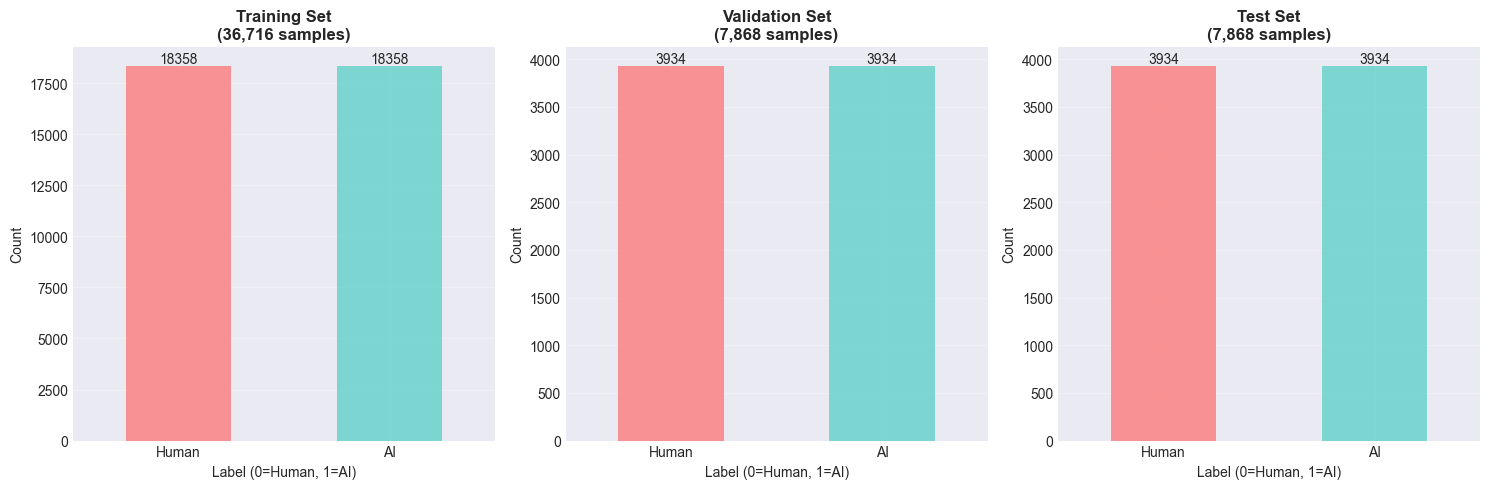

In [22]:
# Visualize splits
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

splits = [
    ('Training', y_train),
    ('Validation', y_val),
    ('Test', y_test)
]

for idx, (name, y_data) in enumerate(splits):
    y_data.value_counts().plot(
        kind='bar', ax=axes[idx], color=['#FF6B6B', '#4ECDC4'], alpha=0.7
    )
    axes[idx].set_title(f'{name} Set\n({len(y_data):,} samples)', fontweight='bold')
    axes[idx].set_xlabel('Label (0=Human, 1=AI)')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xticklabels(['Human', 'AI'], rotation=0)
    axes[idx].grid(True, alpha=0.3)
    
    # Add counts on bars
    for container in axes[idx].containers:
        axes[idx].bar_label(container)

plt.tight_layout()
plt.show()

## 💾 Save Processed Data

In [23]:
print("💾 Saving processed datasets...\n")

# Create DataFrames for each split
df_train = pd.DataFrame({
    'text': X_train.values,
    'label': y_train.values
})

df_val = pd.DataFrame({
    'text': X_val.values,
    'label': y_val.values
})

df_test = pd.DataFrame({
    'text': X_test.values,
    'label': y_test.values
})

# Save to CSV
train_path = config['data']['train_file']
val_path = config['data']['val_file']
test_path = config['data']['test_file']

df_train.to_csv(train_path, index=False)
df_val.to_csv(val_path, index=False)
df_test.to_csv(test_path, index=False)

print(f"✅ Data saved successfully!")
print(f"   Training:   {train_path}")
print(f"   Validation: {val_path}")
print(f"   Test:       {test_path}")

💾 Saving processed datasets...

✅ Data saved successfully!
   Training:   data/processed/train.csv
   Validation: data/processed/val.csv
   Test:       data/processed/test.csv


In [24]:
# Save metadata
metadata = {
    'total_samples': len(df_final),
    'train_samples': len(df_train),
    'val_samples': len(df_val),
    'test_samples': len(df_test),
    'train_ratio': train_size,
    'val_ratio': val_size,
    'test_ratio': test_size,
    'num_classes': 2,
    'class_names': ['Human', 'AI'],
    'balanced': balance_dataset,
    'min_length': min_length,
    'random_state': random_state,
    'sources': df_final['source'].unique().tolist()
}

metadata_path = os.path.join(config['data']['processed_path'], 'metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n✅ Metadata saved: {metadata_path}")


✅ Metadata saved: data/processed\metadata.json


## 📊 Final Summary

In [25]:
print("="*70)
print("📊 DATA PROCESSING COMPLETE!")
print("="*70)
print(f"\n✅ Successfully processed and saved datasets")
print(f"\n📈 Final Statistics:")
print(f"   Total samples collected:  {len(df_combined):,}")
print(f"   Total samples after cleaning: {len(df_final):,}")
print(f"   Training samples:         {len(df_train):,}")
print(f"   Validation samples:       {len(df_val):,}")
print(f"   Test samples:             {len(df_test):,}")
print(f"\n💾 Saved Files:")
print(f"   - {train_path}")
print(f"   - {val_path}")
print(f"   - {test_path}")
print(f"   - {metadata_path}")
print(f"\n🎯 Ready for Feature Engineering!")
print("="*70)

📊 DATA PROCESSING COMPLETE!

✅ Successfully processed and saved datasets

📈 Final Statistics:
   Total samples collected:  78,527
   Total samples after cleaning: 52,452
   Training samples:         36,716
   Validation samples:       7,868
   Test samples:             7,868

💾 Saved Files:
   - data/processed/train.csv
   - data/processed/val.csv
   - data/processed/test.csv
   - data/processed\metadata.json

🎯 Ready for Feature Engineering!


## 🔄 Next Steps

### What We Accomplished:
- ✅ Downloaded HC3 dataset from Hugging Face
- ✅ Created additional diverse samples
- ✅ Combined all data sources
- ✅ Cleaned and preprocessed text data
- ✅ Removed duplicates and invalid entries
- ✅ Balanced class distribution (if configured)
- ✅ Created stratified train/val/test splits
- ✅ Saved processed datasets for modeling

### Next Notebook (03_feature_engineering.ipynb):
1. Load processed datasets
2. Extract TF-IDF features (5000 features, 1-3 grams)
3. Calculate statistical features (entropy, burstiness, perplexity)
4. Extract linguistic features (POS tags, readability scores)
5. Combine all feature types
6. Perform feature analysis and selection
7. Save fitted transformers and feature matrices

---

**📝 Note:** The datasets are now ready for feature extraction and model training!